# Бейзлайн и предобработка

Строим бейзлайн с минимальной предобработкой и по шагам проверяем гипотезы из EDA. Каждый шаг сравниваем с предыдущим по RMSE на логарифме цены в кросс-валидации, а результат складываем в общую таблицу в конце

Для проверки берём две модели, потому что предобработка действует на них по-разному:

- Ridge, линейная модель, чувствительна к масштабу, скошенности и выбросам
- LightGBM, деревья, не зависят от масштаба и монотонных преобразований признаков

Каждый шаг ниже назван по сути гипотезы, а не только номером. Номер в скобках это номер строки из итоговой таблицы в `eda_and_hypotheses.ipynb`, раздел 7, для тех, кто хочет посмотреть исходное основание из EDA

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("../data")
TARGET = "SalePrice"
RANDOM_STATE = 42

train = pd.read_csv(DATA_DIR / "train.csv")
X = train.drop(columns=[TARGET, "Id"])
y = train[TARGET]

print(f"признаков: {X.shape[1]}, домов: {X.shape[0]}")

признаков: 79, домов: 1460


## 1. Схема валидации и метрика

Метрика соревнования, RMSE между логарифмами предсказанной и реальной цены. Считаем её на `log1p`, как и учим модели, разница с обычным логарифмом на ценах порядка десятков тысяч ничтожна

Валидация, 5 фолдов с 3 повторами и разным перемешиванием. Повторы нужны, чтобы небольшие различия между шагами предобработки не тонули в шуме одного разбиения. Разбиение фиксированное, поэтому все шаги сравниваются на одних и тех же фолдах

In [2]:
def rmse(log_true: pd.Series, log_pred: np.ndarray) -> float:
    """Среднеквадратичная ошибка между двумя массивами логарифмов цены"""
    return float(np.sqrt(np.mean((log_true - log_pred) ** 2)))


def cross_validate(model: Pipeline, X: pd.DataFrame, y: pd.Series, log_target: bool = True) -> tuple[float, float]:
    """Считает RMSE на логарифме цены по повторной кросс-валидации

    Если log_target равен True, модель учится на log1p цены и предсказывает
    сразу логарифм. Иначе учится на сырой цене, а предсказание переводится в
    логарифм с обрезкой отрицательных значений нулём, потому что логарифм
    отрицательного числа не определён. Возвращает среднее и стандартное
    отклонение RMSE по всем фолдам
    """
    folds = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
    log_y = np.log1p(y)
    target = log_y if log_target else y
    scores = []
    for fit_idx, valid_idx in folds.split(X):
        fitted = clone(model).fit(X.iloc[fit_idx], target.iloc[fit_idx])
        prediction = fitted.predict(X.iloc[valid_idx])
        if not log_target:
            prediction = np.log1p(np.clip(prediction, 0, None))
        scores.append(rmse(log_y.iloc[valid_idx], prediction))
    return float(np.mean(scores)), float(np.std(scores))

## 2. Бейзлайн

Минимальная предобработка без единой идеи из EDA:

- числовые пропуски заполняем медианой
- категориальные пропуски заполняем самым частым значением, то есть NA в `PoolQC` и `GarageType` для нас пока обычные потерянные значения
- категории кодируем one-hot, числа для Ridge масштабируем
- `MSSubClass` остаётся числом, цена не логарифмируется

Ещё берём тривиальную модель, которая всегда предсказывает медиану цены. Любая настоящая модель обязана её обойти

In [3]:
def build_preprocessor(scale: bool) -> ColumnTransformer:
    """Минимальная предобработка: медиана для чисел, мода и one-hot для категорий

    scale включает стандартизацию чисел, она нужна линейным моделям
    """
    numeric_steps = [SimpleImputer(strategy="median")] + ([StandardScaler()] if scale else [])
    return ColumnTransformer(
        [
            ("numeric", make_pipeline(*numeric_steps), make_column_selector(dtype_include="number")),
            (
                "categorical",
                make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")),
                make_column_selector(dtype_exclude="number"),
            ),
        ]
    )


def build_models() -> dict[str, Pipeline]:
    """Собирает пайплайны Ridge и LightGBM с одинаковой минимальной предобработкой"""
    return {
        "Ridge": make_pipeline(build_preprocessor(scale=True), Ridge(alpha=10)),
        "LightGBM": make_pipeline(
            build_preprocessor(scale=False), LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
        ),
    }


results = []


def evaluate_models(
    experiment: str,
    X: pd.DataFrame,
    y: pd.Series,
    log_target: bool = True,
    build_models_fn=build_models,
) -> pd.DataFrame:
    """Оценивает обе модели на данных X, y и записывает результат в общий список results

    build_models_fn позволяет подставить пайплайны с другой предобработкой,
    например другим кодированием одной колонки, по умолчанию используется
    build_models. Перед таблицей печатает название эксперимента
    """
    print(f"{experiment}: RMSE на логарифме цены по кросс-валидации")
    rows = []
    for model_name, model in build_models_fn().items():
        rmse, std = cross_validate(model, X, y, log_target)
        rows.append({"experiment": experiment, "model": model_name, "rmse": rmse, "std": std})
    results.extend(rows)
    return pd.DataFrame(rows).set_index("model")[["rmse", "std"]]

In [4]:
median_baseline = make_pipeline(DummyRegressor(strategy="median"))
dummy_rmse, dummy_std = cross_validate(median_baseline, X, y, log_target=False)
print(f"медиана цены: RMSE {dummy_rmse:.4f}, std {dummy_std:.4f}")


evaluate_models("1. Бейзлайн, сырая цена", X, y, log_target=False)

медиана цены: RMSE 0.3998, std 0.0177
1. Бейзлайн, сырая цена: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.153805,0.015969
LightGBM,0.135922,0.011898


## 3. Обучение на log1p цены (гипотеза 1)

Скошенность цены в EDA падает с 1.88 до 0.12, поэтому модели должно быть проще учиться на `log1p(SalePrice)`. Меняем только это, всё остальное как в бейзлайне

In [5]:
evaluate_models("2. Обучение на log1p цены", X, y, log_target=True)

2. Обучение на log1p цены: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.143333,0.031774
LightGBM,0.132933,0.011904


In [6]:
def show_results() -> pd.DataFrame:
    """Собирает результаты всех экспериментов в таблицу RMSE по моделям

    Строки идут в порядке добавления экспериментов, pivot по умолчанию
    сортирует их по алфавиту, поэтому порядок восстанавливаем вручную
    """
    results_df = pd.DataFrame(results)
    experiment_order = results_df["experiment"].drop_duplicates()
    table = results_df.pivot(index="experiment", columns="model", values="rmse")
    return table.loc[experiment_order, ["Ridge", "LightGBM"]].round(4)


show_results()

model,Ridge,LightGBM
experiment,,
"1. Бейзлайн, сырая цена",0.1538,0.1359
2. Обучение на log1p цены,0.1433,0.1329


### Выводы: бейзлайн и log1p цены

- Медиана цены даёт RMSE 0.3998, это нижняя планка для сравнения
- Бейзлайн с минимальной предобработкой уже сильно лучше: Ridge 0.1538, LightGBM 0.1359, разброс между фолдами 0.016 и 0.012
- Подтвердилось: обучение на `log1p` цены снижает RMSE у Ridge с 0.1538 до 0.1433 и у LightGBM с 0.1359 до 0.1329. Линейной модели логарифм помогает заметно сильнее, деревьям почти не важен, что ожидаемо для модели, которая делит по порогам
- У Ridge на логарифме вырос разброс между фолдами с 0.016 до 0.032, то есть в каких-то фолдах модель ошибается сильно. Похоже на выбросы, проверим при удалении выбросов дальше
- Дальше все эксперименты идут с обучением на логарифме цены

### Как накапливаются эксперименты

Следующие два шага, про пропуски отсутствия и про `MasVnrType`, проверяем не по отдельности против бейзлайна, а по цепочке: если шаг подтверждается или данные становятся корректнее по смыслу, его результат становится основой для следующего шага, а не откладывается в сторону. Так `X` постепенно превращается в `X_explicit_na`, затем в `X_masvnrtype`, и так далее

Это ближе к тому, как на самом деле собирается финальный пайплайн предобработки, и таблица в конце показывает прогресс по мере накопления решений. Минус в том, что эффект отдельного шага может смешиваться с предыдущими, если шаги затрагивают одни и те же дома или колонки

## 4. Пропуски отсутствия и настоящие пропуски (гипотеза 2)

В бейзлайне все категориальные пропуски заполнялись модой через `SimpleImputer`. Это неверно для колонок, где `NA` означает не потерянное значение, а отсутствие объекта, например `GarageType` у дома без гаража. Заполнение модой превращает "гаража нет" в "самый частый тип гаража", то есть придумывает объект, которого не существует

Разделяем колонки на две группы:

- колонки, где по `data_description` `NA` значит "объекта нет": `Alley`, `Fence`, `PoolQC`, `FireplaceQu`, `MiscFeature`, и все колонки подвала и гаража. Такие пропуски заполняем собственной категорией `NA`, ей мы говорим модели "объекта нет", а не подсовываем случайную категорию
- `GarageYrBlt`, единственная числовая колонка с таким же смыслом пропуска, заполняем нулём, а не медианой, чтобы отсутствие гаража не превращалось в дом среднего возраста

Настоящие пропуски, где индикатор в EDA показал, что объект есть, а поле потеряно, специально не трогаем, они и так остаются пропусками и достаются `SimpleImputer` с заполнением модой, как и было решено

In [7]:
GARAGE_COLUMNS = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
BASEMENT_COLUMNS = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
NO_OBJECT_COLUMNS = ["Alley", "Fence", "PoolQC", "FireplaceQu", "MiscFeature"] + GARAGE_COLUMNS + BASEMENT_COLUMNS


def fill_no_object_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет пропуски отсутствия объекта на явную категорию NA или на 0

    NO_OBJECT_COLUMNS содержит категориальные колонки, где пропуск в исходных
    данных означает отсутствие объекта, а не потерянное значение. GarageYrBlt
    единственная такая же по смыслу числовая колонка
    """
    result = df.copy()
    result[NO_OBJECT_COLUMNS] = result[NO_OBJECT_COLUMNS].fillna("NA")
    result["GarageYrBlt"] = result["GarageYrBlt"].fillna(0)
    return result


X_explicit_na = fill_no_object_columns(X)
evaluate_models("3. Явная категория NA вместо моды", X_explicit_na, y)

3. Явная категория NA вместо моды: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.143135,0.032211
LightGBM,0.133131,0.011589


### Выводы: пропуски отсутствия

- У Ridge RMSE почти не изменился, 0.1433 против 0.1431 в предыдущем шаге, у LightGBM даже немного вырос, 0.1329 против 0.1331. Разница на порядок меньше стандартного отклонения между фолдами, около 0.03 у Ridge и 0.012 у LightGBM, то есть это шум, а не эффект
- Не подтвердилось метрикой: замена моды на явную категорию `NA` не даёт прироста ни одной из моделей. Вероятная причина в том, что "отсутствие объекта" и так сильно связано с числовым индикатором, например нулевой `GarageArea`, и модели уже видят это через него, а мода на маленькой доле пропусков погоды не делает
- Оставляем явную категорию `NA` не ради метрики, а ради корректности: она честно описывает данные и не создаёт из воздуха несуществующие гаражи и подвалы, эта версия `X` идёт дальше

## 5. MasVnrType без путаницы None и NA (гипотеза 3)

При обычном чтении `pd.read_csv` строка `"None"` в `MasVnrType` распознаётся как пропуск, потому что `"None"` есть в списке значений пропуска по умолчанию в pandas. Из-за этого категория "нет облицовки" склеивается с восемью домами, где значение действительно потеряно, и `SimpleImputer` заполняет все 872 пропуска одной модой

Чтобы различить эти случаи, читаем колонку заново с `keep_default_na=False`, тогда `"None"` остаётся строкой, а не пропуском. Возвращаем на место только настоящий пропуск `"NA"`, а `"None"` оставляем как есть, дальше он идёт в one-hot как обычная категория

In [8]:
def fix_masvnrtype(df: pd.DataFrame, path) -> pd.DataFrame:
    """Отличает категорию None от пропуска NA в MasVnrType

    Обычное чтение pd.read_csv распознаёт строку None как пропуск, поэтому
    колонку читаем заново с keep_default_na=False и возвращаем на место
    только настоящий пропуск NA
    """
    raw = pd.read_csv(path, keep_default_na=False)["MasVnrType"]
    result = df.copy()
    result["MasVnrType"] = raw.replace({"NA": np.nan}).values
    return result


X_masvnrtype = fix_masvnrtype(X_explicit_na, DATA_DIR / "train.csv")
print(f"категория None: {(X_masvnrtype['MasVnrType'] == 'None').sum()}, настоящих пропусков: {X_masvnrtype['MasVnrType'].isna().sum()}")
evaluate_models("4. MasVnrType без путаницы None и NA", X_masvnrtype, y)

категория None: 864, настоящих пропусков: 8
4. MasVnrType без путаницы None и NA: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.143187,0.032209
LightGBM,0.133591,0.011816


### Выводы: MasVnrType

- После исправления в данных 864 дома с категорией `None` и 8 домов с настоящим пропуском, ровно как в EDA
- Метрика снова почти не сдвинулась: 8 домов из 1460 слишком мало, чтобы повлиять на RMSE, у Ridge 0.1432 против 0.1431, у LightGBM 0.1336 против 0.1331
- Не подтвердилось метрикой по той же причине, что и пропуски отсутствия, но исправление оставляем: без него дом без облицовки и дом с потерянным значением неотличимы, а на test, где таких пропусков может быть больше, ошибка не такая безобидная

## 6. Ошибки в датах (гипотеза 13)

В EDA раздел про даты нашёл два дефекта, оба в test: `GarageYrBlt` равен 2207 у дома `Id` 2593, и `GarageYrBlt` позже `YrSold` у дома `Id` 2550. Оба этих дома отсутствуют в train, поэтому исправление не повлияет на кросс-валидацию в этом ноутбуке. Показываем исправление здесь, потому что оно понадобится при построении предсказаний на test в следующих ноутбуках

Общее правило, а не точечная правка одного `Id`: год гаража не может быть позже года продажи дома, такой год обрезаем до `YrSold`. Это чинит опечатку 2207 и рассогласование у `Id` 2550 одним и тем же способом

In [9]:
test = pd.read_csv(DATA_DIR / "test.csv")


def fix_garage_year(df: pd.DataFrame) -> pd.DataFrame:
    """Обрезает GarageYrBlt до года продажи, если год гаража позже

    Такое случается при опечатке, например 2207 вместо 2007, и в домах, для
    которых год продажи в данных наступил раньше формальной постройки гаража
    """
    result = df.copy()
    too_late = result["GarageYrBlt"] > result["YrSold"]
    result.loc[too_late, "GarageYrBlt"] = result.loc[too_late, "YrSold"]
    return result


broken = test.loc[test["Id"].isin([2550, 2593]), ["Id", "YearBuilt", "YrSold", "GarageYrBlt"]]
print("до исправления")
print(broken)
print("после исправления")
print(fix_garage_year(test).loc[test["Id"].isin([2550, 2593]), ["Id", "YearBuilt", "YrSold", "GarageYrBlt"]])

до исправления
        Id  YearBuilt  YrSold  GarageYrBlt
1089  2550       2008    2007       2008.0
1132  2593       2006    2007       2207.0
после исправления
        Id  YearBuilt  YrSold  GarageYrBlt
1089  2550       2008    2007       2007.0
1132  2593       2006    2007       2007.0


### Выводы: ошибки в датах

- Правило `GarageYrBlt > YrSold` находит оба дефектных дома и заменяет год гаража на год продажи: у `Id` 2593 вместо опечатки 2207 получаем 2007, у `Id` 2550 вместо 2008 получаем 2007
- Отдельно у `Id` 2550 `YearBuilt` равен 2008, а `YrSold` 2007, то есть дом продан раньше официальной постройки. Возраст дома `HouseAge` для него станет отрицательным, но эта колонка появится только в ноутбуке с feature engineering, поэтому обрезку возраста снизу нулём сделаем там же
- На кросс-валидацию в этом ноутбуке правило не влияет, потому что оба дома есть только в test, добавляем его в общий список исправлений для сборки финального пайплайна

## 7. Удаление выбросов Id 524 и 1299 (гипотеза 4)

В EDA у этих двух домов огромная жилая площадь и максимальное качество, но цена заметно ниже тренда, оба проданы как недостроенные новостройки `Partial`. У Ridge на логарифме цены уже был подозрительно большой разброс между фолдами, 0.032 против 0.012 у LightGBM, вероятная причина, что в некоторых фолдах эти два дома попадают в проверочную часть и портят метрику

Убираем оба дома только из обучающей выборки, `train` целиком состоит из train, поэтому это не нарушает разделение на train и test

In [10]:
OUTLIER_IDS = [524, 1299]


def drop_outliers(df: pd.DataFrame, y: pd.Series, ids: pd.Series, outlier_ids: list[int]) -> tuple[pd.DataFrame, pd.Series]:
    """Убирает из данных дома с указанными Id

    Возвращает признаки и таргет без этих домов, с пересобранным индексом
    """
    keep = ~ids.isin(outlier_ids)
    return df[keep].reset_index(drop=True), y[keep].reset_index(drop=True)


X_no_outliers, y_no_outliers = drop_outliers(X_masvnrtype, y, train["Id"], OUTLIER_IDS)
print(f"домов до удаления: {len(X_masvnrtype)}, после: {len(X_no_outliers)}")
evaluate_models("5. Без выбросов Id 524 и 1299", X_no_outliers, y_no_outliers)

домов до удаления: 1460, после: 1458
5. Без выбросов Id 524 и 1299: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.114667,0.006310
LightGBM,0.127589,0.008341


### Выводы: удаление выбросов

- Подтвердилось, и заметнее, чем все предыдущие шаги вместе взятые. У Ridge RMSE упал с 0.1432 до 0.1147, у LightGBM с 0.1336 до 0.1276
- У Ridge разброс между фолдами упал с 0.0322 до 0.0063, это подтверждает более раннюю догадку про разброс на логарифме цены: именно эти два дома и раздували разброс, попадая в проверочную часть то в одном, то в другом фолде
- Линейная модель выигрывает намного больше деревьев, потому что Ridge проводит одну общую плоскость через все точки, и два дома с ценой сильно ниже тренда тянут её на себя. LightGBM локально режет пространство порогами и может просто отгородить эти два дома в отдельный лист дерева
- Дальше все эксперименты идут без домов `Id` 524 и 1299, `X_no_outliers` и `y_no_outliers` заменяют `X` и `y`

## 8. SaleCondition полезный признак (гипотеза 5)

`SaleCondition` уже входит в данные и проходит через категориальную ветку предобработки, one-hot без специальной обработки. Проверяем не новый признак, а то, несёт ли он сигнал сверх остальных колонок, особенно `Partial`, у которого в EDA цена была выше основной массы при той же площади

Проверяем удалением: сравниваем текущий шаг с `SaleCondition` и тот же шаг без него, оба на данных без выбросов `Id` 524 и 1299

In [11]:
X_no_salecondition = X_no_outliers.drop(columns=["SaleCondition"])
evaluate_models("6. Без SaleCondition", X_no_salecondition, y_no_outliers)

6. Без SaleCondition: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.115789,0.007119
LightGBM,0.128730,0.008519


### Выводы: SaleCondition

- Без `SaleCondition` RMSE у обеих моделей растёт: у Ridge с 0.1147 до 0.1158, у LightGBM с 0.1276 до 0.1287
- Подтвердилось у обеих моделей, `SaleCondition` несёт сигнал сверх остальных признаков, включая площадь и качество. Прирост небольшой, но одного порядка у линейной модели и у деревьев, значит это не совпадение подгонки одной модели
- Колонку оставляем, дальше эксперименты продолжаются на `X_no_outliers`

Сводная таблица на данный момент

In [12]:
show_results()

model,Ridge,LightGBM
experiment,,
"1. Бейзлайн, сырая цена",0.1538,0.1359
2. Обучение на log1p цены,0.1433,0.1329
3. Явная категория NA вместо моды,0.1431,0.1331
4. MasVnrType без путаницы None и NA,0.1432,0.1336
5. Без выбросов Id 524 и 1299,0.1147,0.1276
6. Без SaleCondition,0.1158,0.1287


## 9. log1p для площадей (гипотеза 6)

В EDA `log1p` действовал на корреляцию с ценой по-разному: у `LotArea`, где нулей нет, корреляция выросла с 0.26 до 0.40, а у `TotalBsmtSF`, где 3% домов без подвала, упала с 0.61 до 0.37. В EDA предполагалось, что для колонок с нулями лучше сначала добавить флаг наличия, а потом уже брать `log1p`

Проверяем это в два шага, отдельно для колонок без нулей и отдельно для колонок с нулями, чтобы не смешать два разных эффекта в одном числе

In [13]:
NO_ZERO_AREA_COLUMNS = ["LotFrontage", "LotArea", "1stFlrSF", "GrLivArea"]
ZERO_HEAVY_AREA_COLUMNS = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "2ndFlrSF",
    "LowQualFinSF", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]


def log_transform(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Заменяет перечисленные колонки на их log1p"""
    result = df.copy()
    result[columns] = np.log1p(result[columns])
    return result


X_log_no_zero = log_transform(X_no_outliers, NO_ZERO_AREA_COLUMNS)
evaluate_models("7. log1p для площадей без нулей", X_log_no_zero, y_no_outliers)

7. log1p для площадей без нулей: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111167,0.006786
LightGBM,0.127594,0.008352


In [14]:
def add_existence_flags(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Добавляет для каждой колонки бинарный флаг Has с признаком column больше нуля"""
    result = df.copy()
    for column in columns:
        result[f"Has{column}"] = (result[column] > 0).astype(int)
    return result


X_log_with_flags = add_existence_flags(X_log_no_zero, ZERO_HEAVY_AREA_COLUMNS)
X_log_with_flags = log_transform(X_log_with_flags, ZERO_HEAVY_AREA_COLUMNS)
evaluate_models("8. Плюс флаг и log1p для площадей с нулями", X_log_with_flags, y_no_outliers)

8. Плюс флаг и log1p для площадей с нулями: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111976,0.007141
LightGBM,0.127594,0.008416


### Выводы: log1p площадей

- Подтвердилось только наполовину. `log1p` для колонок без нулей заметно помогает Ridge, RMSE падает с 0.1147 до 0.1112, LightGBM почти не реагирует, 0.1276 в обоих случаях, деревьям монотонное преобразование признака не важно
- Добавление флага и `log1p` для колонок с нулями не помогает, а слегка вредит: RMSE у Ridge растёт обратно до 0.1120, у LightGBM остаётся на месте, 0.1276
- Похоже, что для колонок с нулями сам ноль уже несёт достаточно сигнала через величину, а `log1p` только сжимает разницу между большими значениями, как и показывала упавшая корреляция `TotalBsmtSF` в EDA
- Оставляем только `log1p` для колонок без нулей, `X_log_no_zero` идёт дальше как основа для следующих шагов, колонки с нулями остаются как есть

## 10. Удаление скоррелированных колонок (гипотеза 7)

В EDA нашлись четыре пары с корреляцией от 0.82 до 0.88: `GarageArea` и `GarageCars`, `GarageYrBlt` и `YearBuilt`, `TotRmsAbvGrd` и `GrLivArea`, `1stFlrSF` и `TotalBsmtSF`. Проверяем: убрать по одной колонке из каждой пары не ухудшит линейные модели, потому что вторая колонка пары несёт почти ту же информацию

In [15]:
CORRELATED_COLUMNS = ["GarageArea", "GarageYrBlt", "TotRmsAbvGrd", "1stFlrSF"]

X_no_correlated = X_log_no_zero.drop(columns=CORRELATED_COLUMNS)
evaluate_models("9. Без скоррелированных колонок", X_no_correlated, y_no_outliers)

9. Без скоррелированных колонок: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111568,0.006374
LightGBM,0.126603,0.008440


### Выводы: скоррелированные колонки

- Не подтвердилось для Ridge: RMSE слегка вырос, с 0.1112 до 0.1116, разница намного меньше стандартного отклонения между фолдами, около 0.007, то есть в пределах шума, но и улучшения нет
- LightGBM наоборот заметнее улучшился, с 0.1276 до 0.1266. Лишние скоррелированные колонки отнимали у дерева место в разбиениях, которое теперь достаётся более информативным признакам
- Одна общая линейная модель Ridge не страдает от мультиколлинеарности так, как ожидалось: регуляризация уже сама сглаживает вклад скоррелированных колонок, поэтому явное удаление почти ничего не меняет
- Удаление оставляем ради упрощения набора признаков, а не ради метрики, `X_no_correlated` идёт дальше как основа для следующих шагов

## 11. Utilities и редкие категории (гипотеза 8)

В EDA пять колонок почти константны, самое частое значение встречается у 90% домов и больше: `Utilities` 99.9%, `Street` 99.6%, `Condition2` 99%, `RoofMatl` 98.2%, `Heating` 97.8%. У `Utilities` всего один дом с другим значением, на нём учиться нельзя, это первый кандидат на удаление

Для остальных четырёх колонок в EDA редкое значение всё же показывало разницу в медианной цене, например у `RoofMatl` 235 тысяч против 162 и у `Heating` 117 тысяч против 165. Отсюда идея, что такие колонки лучше не удалять целиком, а объединить редкие категории в одну, чтобы не терять этот сигнал

Проверяем по частям: сначала одну `Utilities`, потом сравниваем удаление остальных четырёх целиком с объединением их редких категорий

In [16]:
X_no_utilities = X_no_correlated.drop(columns=["Utilities"])
evaluate_models("10. Без Utilities", X_no_utilities, y_no_outliers)

10. Без Utilities: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111567,0.006376
LightGBM,0.126603,0.008440


In [17]:
NEAR_CONSTANT_COLUMNS = ["Street", "Condition2", "RoofMatl", "Heating"]

X_no_near_constant = X_no_utilities.drop(columns=NEAR_CONSTANT_COLUMNS)
evaluate_models("11. Без остальных почти константных колонок", X_no_near_constant, y_no_outliers)

11. Без остальных почти константных колонок: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.11135,0.006428
LightGBM,0.12643,0.008333


In [18]:
def merge_rare_categories(df: pd.DataFrame, columns: list[str], rare_threshold: float = 0.01) -> pd.DataFrame:
    """Объединяет редкие категории перечисленных колонок в одну категорию Rare

    Категория считается редкой, если её доля в колонке меньше rare_threshold
    """
    result = df.copy()
    for column in columns:
        shares = result[column].value_counts(normalize=True)
        rare_values = shares[shares < rare_threshold].index
        result[column] = result[column].where(~result[column].isin(rare_values), "Rare")
    return result


X_merged_rare = merge_rare_categories(X_no_utilities, NEAR_CONSTANT_COLUMNS)
evaluate_models("12. Редкие категории объединены, колонки сохранены", X_merged_rare, y_no_outliers)

12. Редкие категории объединены, колонки сохранены: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111497,0.006361
LightGBM,0.126603,0.008440


### Выводы: Utilities и редкие категории

- Первая часть подтвердилась: удаление `Utilities` ничего не меняет, RMSE у обеих моделей совпадает с предыдущим шагом до пятого знака, ожидаемо для колонки с одним отличающимся домом из 1458
- Вторая часть не подтвердилась. Полное удаление `Street`, `Condition2`, `RoofMatl` и `Heating` дало RMSE 0.1114 у Ridge и 0.1264 у LightGBM, а объединение их редких категорий в одну дало 0.1115 и 0.1266, то есть чуть хуже полного удаления у обеих моделей, а не лучше
- Вероятная причина в размере групп: редкая категория у этих колонок это 26-32 дома на весь train, а в кросс-валидации фолд ещё меньше. Оценить коэффициент для такой маленькой группы надёжно нельзя, поэтому объединение не помогает, хотя медианная цена в EDA у этих групп отличалась заметно
- Оставляем полное удаление этих четырёх колонок вместе с `Utilities`, `X_no_near_constant` идёт дальше как основа для следующих шагов. `CentralAir` эта проверка не касалась, у него похожая по размеру редкая категория, 95 из 1460, но там она чётко и стабильно связана с ценой, и колонку мы не трогаем

## 12. Кодирование категориальных признаков (гипотезы 9, 10 и 11)

Сейчас все категориальные колонки идут через одинаковый one-hot, дальше проверяем три альтернативы для конкретных групп колонок

Колонки шкал качества уже без пропусков к этому шагу, отсутствие объекта заполнено категорией NA ещё на шаге про пропуски отсутствия

### Порядковое кодирование монотонных шкал (гипотеза 9)

У ExterQual, BsmtQual, BsmtCond, HeatingQC, KitchenQual, FireplaceQu медианная цена в EDA строго растёт от Po до Ex, поэтому пробуем заменить шкалу числами от 0 до 5 вместо one-hot. После такой замены колонка становится числовой и автоматически попадает в числовую ветку предобработки, менять build_preprocessor не нужно

In [19]:
ORDINAL_QUALITY_COLUMNS = ["ExterQual", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu"]
QUALITY_ORDER = {"NA": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}


def ordinal_encode_quality(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Заменяет шкалы качества числами от 0 до 5 по порядку QUALITY_ORDER"""
    result = df.copy()
    for column in columns:
        result[column] = result[column].map(QUALITY_ORDER)
    return result


X_ordinal = ordinal_encode_quality(X_no_near_constant, ORDINAL_QUALITY_COLUMNS)
evaluate_models("13. Порядковое кодирование шкал качества", X_ordinal, y_no_outliers)

13. Порядковое кодирование шкал качества: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111718,0.006139
LightGBM,0.125650,0.006411


### Выводы: порядковое кодирование

- У Ridge RMSE слегка вырос, с 0.1114 до 0.1117, разница меньше стандартного отклонения между фолдами, около 0.006, то есть в пределах шума
- У LightGBM RMSE упал с 0.1264 до 0.1257, тоже небольшая разница, но устойчиво в сторону улучшения
- Подтвердилось в исходной формулировке, порядковое кодирование не хуже one-hot, а колонок становится меньше, `X_ordinal` идёт дальше

### Бинарный флаг вместо несогласованных шкал (гипотеза 10)

У ExterCond, GarageQual, GarageCond, PoolQC порядок цены по шкале в EDA нарушается, а редкие уровни вроде Gd у GarageQual держатся на 14 домах. Пробуем самый простой вариант, бинарный флаг IsTA, вместо one-hot на все уровни этих четырёх колонок

In [20]:
NONMONOTONIC_QUALITY_COLUMNS = ["ExterCond", "GarageQual", "GarageCond", "PoolQC"]


def binarize_is_ta(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Заменяет каждую колонку бинарным флагом IsTA, равным TA или нет"""
    result = df.copy()
    for column in columns:
        result[f"Is{column}TA"] = (result[column] == "TA").astype(int)
    return result.drop(columns=columns)


X_binary_flags = binarize_is_ta(X_ordinal, NONMONOTONIC_QUALITY_COLUMNS)
evaluate_models("14. Бинарный флаг IsTA вместо шкалы", X_binary_flags, y_no_outliers)

14. Бинарный флаг IsTA вместо шкалы: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111801,0.006155
LightGBM,0.125401,0.007108


### Выводы: бинарный флаг IsTA

- У Ridge RMSE почти не изменился, 0.1117 против 0.1118, у LightGBM даже чуть улучшился, 0.1257 против 0.1254. Обе разницы меньше стандартного отклонения между фолдами
- Заранее ожидалась просадка у LightGBM из-за потери сигнала мелких групп вроде 14 домов с `Gd` у `GarageQual`, но на деле разницы нет ни в одну, ни в другую сторону, результат неотличим от шума
- Сигнала ни за, ни против нет, оставляем более простой one-hot вариант без изменений и не добавляем этот шаг в пайплайн, дальше продолжаем с `X_ordinal`

### Target encoding для Neighborhood (гипотеза 11)

У Neighborhood 25 категорий и чёткая связь медианной цены с районом. One-hot даёт 25 колонок. Target encoding заменяет колонку на среднюю цену по району, посчитанную только по обучающей части, TargetEncoder из scikit-learn сам делает это внутри фолдов, без утечки

Здесь предобработка отличается только для одной колонки, поэтому нужен отдельный пайплайн, а не общий build_preprocessor

In [21]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder


def build_models_target_neighborhood() -> dict[str, Pipeline]:
    """Собирает Ridge и LightGBM с target encoding для Neighborhood вместо one-hot"""
    models = {}
    for model_name, estimator, scale in [
        ("Ridge", Ridge(alpha=10), True),
        ("LightGBM", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1), False),
    ]:
        numeric_steps = [SimpleImputer(strategy="median")] + ([StandardScaler()] if scale else [])
        preprocessor = ColumnTransformer(
            [
                ("numeric", make_pipeline(*numeric_steps), make_column_selector(dtype_include="number")),
                ("neighborhood", TargetEncoder(target_type="continuous", cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)), ["Neighborhood"]),
                (
                    "categorical",
                    make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")),
                    make_column_selector(dtype_exclude="number", pattern="^(?!Neighborhood$)"),
                ),
            ]
        )
        models[model_name] = make_pipeline(preprocessor, estimator)
    return models


evaluate_models(
    "15. Target encoding для Neighborhood",
    X_ordinal,
    y_no_outliers,
    build_models_fn=build_models_target_neighborhood,
)

15. Target encoding для Neighborhood: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.114069,0.006349
LightGBM,0.124949,0.006663


### Выводы: target encoding

- Не подтвердилось. У Ridge RMSE заметно вырос, с 0.1118 до 0.1141, это больше стандартного отклонения между фолдами. У LightGBM небольшое улучшение, с 0.1254 до 0.1249
- Ridge теряет от замены 25 колонок на одну: у one-hot каждый район получает свой независимый коэффициент, а после target encoding это сжимается в одно число, и модель теряет часть различий между районами
- Идею отклоняем, `Neighborhood` остаётся one-hot

Отдельно нашлась ошибка воспроизводимости: у `TargetEncoder` не был закреплён `random_state`, из-за чего числа этого шага менялись при каждом перезапуске ноутбука. Исправлено передачей `cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)`, два подряд запуска с чистого ядра теперь дают одинаковый результат

### One-hot и неизвестные категории (гипотеза 12)

Этот пункт отдельно измерить нельзя, handle_unknown="ignore" в OneHotEncoder уже стоит с самого бейзлайна. Вместо этого показываем, что механизм действительно нужен и работает: берём одно разбиение кросс-валидации и смотрим, какие категории попадают в проверочную часть, но отсутствуют в обучающей

In [22]:
def unseen_categories(df: pd.DataFrame, train_idx: np.ndarray, valid_idx: np.ndarray) -> dict[str, set]:
    """Находит категории, которые есть в проверочной части фолда, но отсутствуют в обучающей"""
    unseen = {}
    for column in df.select_dtypes(exclude="number").columns:
        train_values = set(df.loc[train_idx, column].dropna().unique())
        valid_values = set(df.loc[valid_idx, column].dropna().unique())
        only_in_valid = valid_values - train_values
        if only_in_valid:
            unseen[column] = only_in_valid
    return unseen


first_fold_train, first_fold_valid = next(iter(RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE).split(X_ordinal)))
unseen_categories(X_ordinal, first_fold_train, first_fold_valid)

{'Electrical': {'Mix'}, 'Functional': {'Sev'}}

### Выводы: неизвестные категории

- В показанном разбиении `Electrical` получает категорию `Mix`, а `Functional` категорию `Sev`, которых не было в обучающей части. Такое неизбежно на случайных разбиениях с редкими категориями, и это тот же сценарий, из-за которого код `150` в `MSSubClass` встречается в test, но не в train
- За все 15 фолдов кросс-валидации ни один запуск не упал с ошибкой, значит `handle_unknown="ignore"` действительно защищает от таких случаев на протяжении всего ноутбука, пункт подтверждён самим фактом, что эксперименты выше вообще посчитались

### Итог по кодированию категорий

Из трёх проверенных идей осталась одна: порядковое кодирование шести монотонных шкал качества. Бинарный флаг для несогласованных шкал и target encoding для Neighborhood ухудшили результат и отклонены. X_ordinal и y_no_outliers идут дальше как основа для следующих шагов

## Итоги ноутбука

Проверили пункты 1 до 13 из итоговой таблицы EDA, кроме SaleCondition, который только подтвердил уже включённую колонку, и пункта про сравнение CV и лидерборда, который можно проверить только после первого сабмита на Kaggle

Что приняли в рабочий набор данных, `X_ordinal` и `y_no_outliers`:

- обучение на `log1p(SalePrice)`
- явная категория `NA` для пропусков отсутствия объекта и `MasVnrType` без путаницы `None` и `NA`, оба приняты ради корректности данных, а не ради метрики
- удаление из train двух выбросов `Id` 524 и 1299, самый большой прирост метрики за весь ноутбук
- `log1p` для площадей без нулей, частичное принятие
- удаление скоррелированных колонок и всех почти константных колонок кроме `CentralAir`
- порядковое кодирование шести монотонных шкал качества
- исправление `GarageYrBlt` в test, никак не проверяется на train

Что проверили и отклонили: флаг с логарифмом для площадей с нулями, бинарный флаг `IsTA` для несогласованных шкал качества, target encoding для `Neighborhood`, объединение редких категорий вместо удаления колонок. Каждый раз метрика становилась хуже или результат был неотличим от шума

Путь метрики от бейзлайна на логарифме цены, без каких-либо преобразований из EDA, до финального набора признаков: у Ridge RMSE упал с 0.1433 до 0.1117, у LightGBM с 0.1329 до 0.1257. Почти весь прирост у обеих моделей дало удаление двух выбросов, остальные шаги уточняли результат на десятые и сотые доли

Дальше пункты 14 до 17 из таблицы EDA, про составные признаки и отбор дат, идут в отдельный ноутбук с feature engineering, а пункт про сравнение CV и лидерборда проверяется после первого сабмита

In [23]:
show_results()

model,Ridge,LightGBM
experiment,,
"1. Бейзлайн, сырая цена",0.1538,0.1359
2. Обучение на log1p цены,0.1433,0.1329
3. Явная категория NA вместо моды,0.1431,0.1331
4. MasVnrType без путаницы None и NA,0.1432,0.1336
5. Без выбросов Id 524 и 1299,0.1147,0.1276
6. Без SaleCondition,0.1158,0.1287
7. log1p для площадей без нулей,0.1112,0.1276
8. Плюс флаг и log1p для площадей с нулями,0.1120,0.1276
9. Без скоррелированных колонок,0.1116,0.1266


### График изменения RMSE по экспериментам

16 точек, медианный бейзлайн и 15 экспериментов из таблицы выше, отдельно для Ridge и LightGBM, чтобы сравнивать модели на одинаковой шкале по оси Y

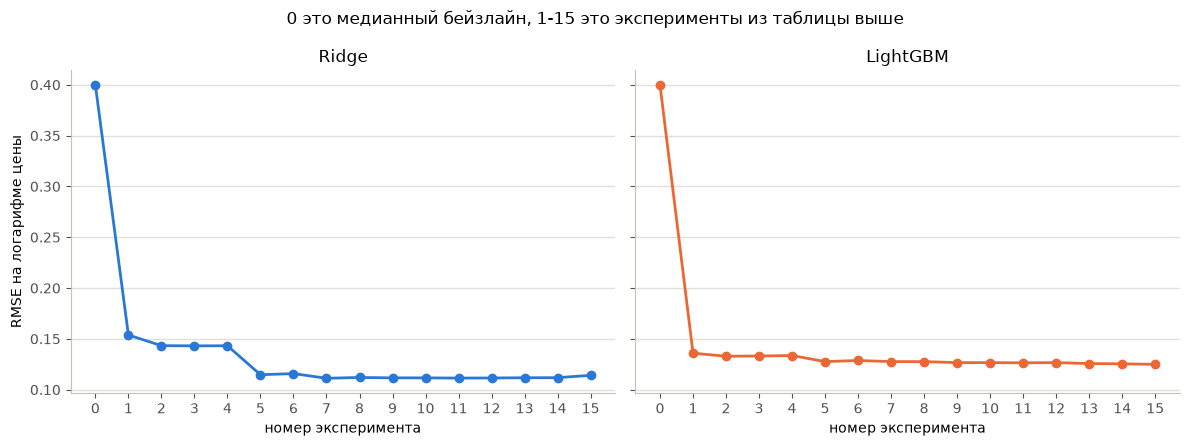

In [24]:
def plot_rmse_progress(results_table: pd.DataFrame, title: str, median_rmse: float | None = None) -> None:
    """Строит график RMSE по всем экспериментам ноутбука отдельно для Ridge и LightGBM

    median_rmse добавляется как нулевая точка, это RMSE медианного бейзлайна
    без обучения модели. Если median_rmse не передан, график строится только
    по results_table. Подписи по оси X это номер эксперимента из results_table
    """
    labels = [experiment.split(".")[0] for experiment in results_table.index]
    colors = {"Ridge": "#2a78d6", "LightGBM": "#eb6834"}
    if median_rmse is not None:
        labels = ["0"] + labels

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, model_name in zip(axes, ["Ridge", "LightGBM"]):
        values = results_table[model_name].tolist()
        if median_rmse is not None:
            values = [median_rmse] + values
        ax.plot(
            labels,
            values,
            color=colors[model_name],
            linewidth=2,
            marker="o",
            markersize=6,
        )
        ax.set_title(model_name)
        ax.set_xlabel("номер эксперимента")
        ax.grid(axis="y", color="#e1e0d9", linewidth=1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#52514e")

    axes[0].set_ylabel("RMSE на логарифме цены")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_rmse_progress(show_results(), "0 это медианный бейзлайн, 1-15 это эксперименты из таблицы выше", dummy_rmse)

Самый большой обрыв на обоих графиках, между точками 0 и 1, это разница между медианным бейзлайном и любой настоящей моделью, ожидаемо и не связано с самими экспериментами. Второй, более пологий обрыв между точками 4 и 5 это удаление выбросов `Id` 524 и 1299, крупнейшее улучшение среди самих экспериментов. После него обе кривые выходят на плато, а дальнейшие эксперименты только слегка покачивают линию вверх и вниз

### Тот же график без медианного бейзлайна

Медианный бейзлайн на предыдущем графике сжимал шкалу и прятал разницу между самими экспериментами. Без него масштаб читается приятнее

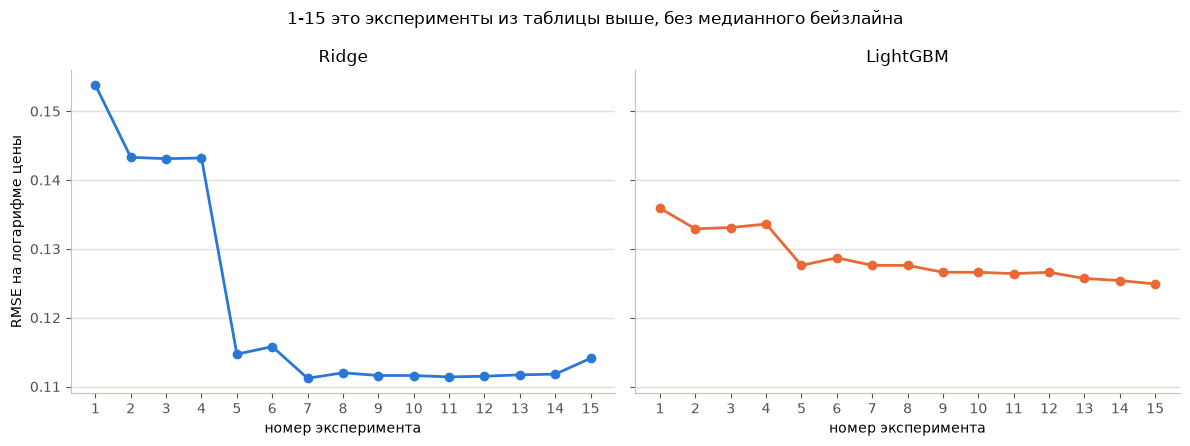

In [25]:
plot_rmse_progress(show_results(), "1-15 это эксперименты из таблицы выше, без медианного бейзлайна")